In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM , Dense
import numpy as np
import pandas as pd


In [34]:
df_loaded=pd.read_csv('/content/module_159_data.csv')

X=df_loaded.drop('target',axis=1).values
y=df_loaded['target'].values


X=X.reshape(X.shape[0],X.shape[1],1)

In [35]:
model=Sequential([
    LSTM(32,input_shape=(10,1)),
    Dense(1,activation='sigmoid')
])

model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

model.fit(X,y,epochs=20,batch_size=32,validation_split=0.2)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.5019 - loss: 0.6798 - val_accuracy: 0.4450 - val_loss: 0.6768
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6800 - loss: 0.5704 - val_accuracy: 0.7975 - val_loss: 0.4618
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8031 - loss: 0.4303 - val_accuracy: 0.8150 - val_loss: 0.4061
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8369 - loss: 0.3642 - val_accuracy: 0.8225 - val_loss: 0.3539
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8506 - loss: 0.3380 - val_accuracy: 0.8375 - val_loss: 0.3716
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8756 - loss: 0.2917 - val_accuracy: 0.8425 - val_loss: 0.3135
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8894 - loss: 0.2684 - val_accuracy: 0.8425 - val_loss: 0.3248
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8900 - loss: 0.2571 - val_accuracy: 0.8550 - val_loss: 0.2973
Ep

In [36]:
model.evaluate(X,y,verbose=1)[1]

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9320 - loss: 0.1676


0.9319999814033508

In [37]:
df=pd.read_csv('/content/ecommerce_sales_analytics_5000.csv')
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [38]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

# Weekday (0 = Monday, 6 = Sunday)
df['weekday'] = df['order_date'].dt.weekday

In [39]:
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,day,weekday
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,1,5
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,2,6
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,3,0
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,4,1
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,5,2


In [40]:
df['is_month_start']=df['order_date'].dt.is_month_start.astype(int)
df['is_month_end']=df['order_date'].dt.is_month_end.astype(int)
df

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,day,weekday,is_month_start,is_month_end
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,2022,1,1,5,1,0
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,2022,1,2,6,0,0
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,2022,1,3,0,0,0
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,2022,1,4,1,0,0
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,2022,1,5,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,14996,2035-09-05,1289,Clothing,West,2,371.74,0.27,COD,3,2.3,542.74,2035,9,5,2,0,0
4996,14997,2035-09-06,1294,Beauty,North,3,553.67,0.14,COD,11,2.2,1428.47,2035,9,6,3,0,0
4997,14998,2035-09-07,1450,Beauty,West,3,77.22,0.24,Wallet,6,3.4,176.06,2035,9,7,4,0,0
4998,14999,2035-09-08,1903,Electronics,South,4,138.41,0.21,COD,4,2.8,437.38,2035,9,8,5,0,0


In [41]:
df = df.drop('order_id', axis=1)

In [44]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['product_category','region','payment_method']

for col in categorical_cols:
    encoder = LabelEncoder() # Create a new encoder for each column
    df[col] = encoder.fit_transform(df[col])

In [45]:
df

,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,day,weekday,is_month_start,is_month_end
0,2022-01-01,1102,0,2,7,373.65,0.28,2,10,4.7,1883.20,2022,1,1,5,1,0
1,2022-01-02,1435,1,2,7,47.74,0.09,1,6,3.9,304.10,2022,1,2,6,0,0
2,2022-01-03,1860,0,0,3,311.28,0.31,0,6,2.5,644.35,2022,1,3,0,0,0
3,2022-01-04,1270,2,3,5,524.47,0.02,2,6,1.6,2569.90,2022,1,4,1,0,0
4,2022-01-05,1106,1,3,5,139.87,0.33,2,4,4.9,468.56,2022,1,5,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,2035-09-05,1289,1,3,2,371.74,0.27,0,3,2.3,542.74,2035,9,5,2,0,0
4996,2035-09-06,1294,0,1,3,553.67,0.14,0,11,2.2,1428.47,2035,9,6,3,0,0
4997,2035-09-07,1450,0,3,3,77.22,0.24,2,6,3.4,176.06,2035,9,7,4,0,0
4998,2035-09-08,1903,2,2,4,138.41,0.21,0,4,2.8,437.38,2035,9,8,5,0,0


In [48]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = [
    'quantity',
    'unit_price',
    'discount',
    'delivery_days',
    'customer_rating',
    'year',
    'month',
    'day',
    'weekday'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

In [50]:
df.head(1)

,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,year,month,day,weekday,is_month_start,is_month_end
0,2022-01-01,1102,0,2,1.462828,0.385431,0.986412,2,1.230975,1.491025,1883.2,-1.606501,-1.58454,-1.670674,0.999375,1,0


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [54]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM
model=Sequential([
    LSTM(128, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)  # revenue prediction
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2636 - mae: 0.4445 - val_loss: 0.2022 - val_mae: 0.4331
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1701 - mae: 0.3977 - val_loss: 0.1584 - val_mae: 0.3548
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1632 - mae: 0.3641 - val_loss: 0.1293 - val_mae: 0.3363
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1286 - mae: 0.3286 - val_loss: 0.1098 - val_mae: 0.2984
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1105 - mae: 0.2886 - val_loss: 0.1066 - val_mae: 0.2769
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0947 - mae: 0.2543 - val_loss: 0.0770 - val_mae: 0.2305
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0834 - mae: 0.2314 - val_loss: 0.0687 - val_mae: 0.1953
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0739 - mae: 0.2061 - val_loss: 0.0556 - val_mae: 0.1780
Epoch 9/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0642 - mae:

In [56]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 0.0129 - mae: 0.0478
Test Loss: 0.012943997047841549
Test MAE: 0.0478370301425457


In [57]:
y_pred = model.predict(X_test)

print(y_pred[:5])

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step
[[1.0175581 ]
 [0.00643901]
 [0.99840456]
 [1.0051341 ]
 [0.02879306]]


In [58]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9479311108589172


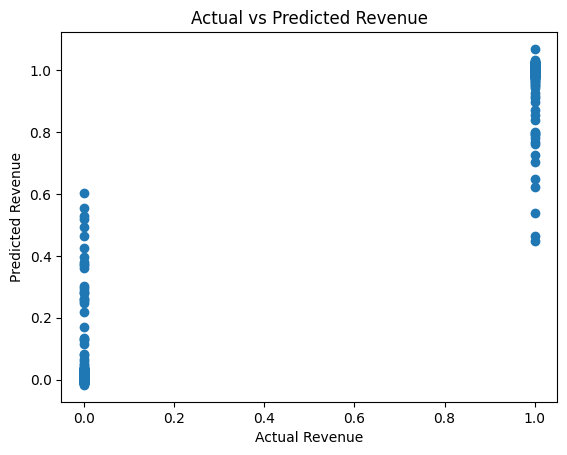

In [59]:
import matplotlib.pyplot as plt



plt.scatter(y_test, y_pred)

plt.xlabel("Actual Revenue")

plt.ylabel("Predicted Revenue")

plt.title("Actual vs Predicted Revenue")

plt.show()

In [60]:
model.save("revenue_model.h5")